In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import os

# Notes about mojito noise model:

- The noises are equal, the arm lengths are not
- The test mass ASDs are `3e-15`
- The OMS ASDs are `15e-12`
- No clock noise, no TTL
- **The data come in fractional frequency**, the strain is $X_\mathrm{strain} \equiv X_\mathrm{raw} / \nu_0$
- The central laser frequency $\nu_0 \simeq (1064\, \mathrm{nm}) / c$ is saved in the root-level HDF5 attributes

## instrument config

In [78]:
'''
instru_config = {
    # Random seed
    "seed": 0,
    # Sampling parameters
    "size": instru_size,
    "dt": instru_dt,
    "t0": instru_t0,
    # Physics simulation sampling and filtering
    "physics_upsampling": 4,
    "aafilter": ("kaiser", 240, 1.1, 2.9),
    "noises_f_min_hz": 5e-6,
    # Telemetry sampling
    "telemetry_downsampling": 86400 * 4,
    "initial_telemetry_size": 0,
    # Inter-spacecraft propagation
    "orbits": orbits_file,
    "orbit_dataset": "tcb/ltt",
    "gws": None,
    "interpolation": ("lagrange", 31),
    # Artifacts
    "glitches": None,
    # Laser locking and frequency plan
    "lock": "six",
    "fplan": "static",
    "laser_asds": 0.0,
    "laser_shape": "white",
    "central_freq": 2.816e14,
    "offset_freqs": {
        "12": 0.0,
        "23": 11e6,
        "31": 7.5e6,
        "13": 16e6,
        "32": -12e6,
        "21": -7e6,
    },
    # Laser phase modulation
    "modulation_asds": 0.0,
    "modulation_freqs": 0.0,
    "tdir_modulations": None,
    # Clocks
    "clock_asds": 0.0,
    "clock_offsets": 0.0,
    "clock_freqoffsets": 0.0,
    "clock_freqlindrifts": 0.0,
    "clock_freqquaddrifts": 0.0,
    "clock_f_min_hz": 5e-6,
    # Clock inversion
    "clockinv_tolerance": 1e-10,
    "clockinv_maxiter": 5,
    # Optical pathlength noises
    "backlink_asds": 0.0,
    "backlink_fknees": 0.0,
    "testmass_asds": 3.0e-15,
    "testmass_fknees": 0.4e-3,
    "testmass_fbreak": 8e-3,
    "testmass_frelax": 0.0,
    "testmass_shape": "original",
    "oms_asds": (15.0e-12, 0.0, 0.0, 0.0, 0.0, 0.0),
    "oms_fknees": 2e-3,
    # MOC time correlation
    "moc_time_correlation_asds": 0.0,
    # Tilt-to-length (TTL)
    "ttl_coeffs": (0.0, 0.0, 0.0, 0.0),
    "sc_angular_jitter_asds": (0.0, 0.0, 0.0),
    "sc_angular_jitter_fknees": (0.0, 0.0, 0.0),
    "mosa_angular_jitter_asds": (0.0, 0.0),
    "mosa_angular_jitter_fknees": (0.0, 0.0),
    "mosa_angles": {"12": 30, "23": 30, "31": 30, "13": -30, "32": -30, "21": -30},
    "dws_asds": 0.0,
    # Lateral jitters
    "mosa_longitudinal_jitter_asds": 0.0,
    # Pseudo-ranging
    "ranging_biases": 0,
    "ranging_asds": 0.0,
    "prn_ambiguity": None,
    # Electronic delays
    "electro_delays": (0, 0, 0),
}
'''

'\ninstru_config = {\n    # Random seed\n    "seed": 0,\n    # Sampling parameters\n    "size": instru_size,\n    "dt": instru_dt,\n    "t0": instru_t0,\n    # Physics simulation sampling and filtering\n    "physics_upsampling": 4,\n    "aafilter": ("kaiser", 240, 1.1, 2.9),\n    "noises_f_min_hz": 5e-6,\n    # Telemetry sampling\n    "telemetry_downsampling": 86400 * 4,\n    "initial_telemetry_size": 0,\n    # Inter-spacecraft propagation\n    "orbits": orbits_file,\n    "orbit_dataset": "tcb/ltt",\n    "gws": None,\n    "interpolation": ("lagrange", 31),\n    # Artifacts\n    "glitches": None,\n    # Laser locking and frequency plan\n    "lock": "six",\n    "fplan": "static",\n    "laser_asds": 0.0,\n    "laser_shape": "white",\n    "central_freq": 2.816e14,\n    "offset_freqs": {\n        "12": 0.0,\n        "23": 11e6,\n        "31": 7.5e6,\n        "13": 16e6,\n        "32": -12e6,\n        "21": -7e6,\n    },\n    # Laser phase modulation\n    "modulation_asds": 0.0,\n    "modula

# load noise data

In [12]:
f = h5py.File("./NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5")

In [13]:
fnoise_min = f['noise_estimates/log_frequency_sampling'].attrs['fmin']
fnoise_max = f['noise_estimates/log_frequency_sampling'].attrs['fmax']
fnoise_size = f['noise_estimates/log_frequency_sampling'].attrs['size']
fnoise  = np.geomspace(fnoise_min, fnoise_max, num=fnoise_size)

In [14]:
Cxx = np.array(f['noise_estimates']['XYZ'][0,:,0,0])
Cxy = np.array(f['noise_estimates']['XYZ'][0,:,0,1])
Cxz = np.array(f['noise_estimates']['XYZ'][0,:,0,2])
Cyx = np.array(f['noise_estimates']['XYZ'][0,:,1,0])
Cyy = np.array(f['noise_estimates']['XYZ'][0,:,1,1])
Cyz = np.array(f['noise_estimates']['XYZ'][0,:,1,2])
Czx = np.array(f['noise_estimates']['XYZ'][0,:,2,0])
Czy = np.array(f['noise_estimates']['XYZ'][0,:,2,1])
Czz = np.array(f['noise_estimates']['XYZ'][0,:,2,2])

In [15]:
dataX = np.array(f['tdis/X2'])
dataY = np.array(f['tdis/Y2'])
dataZ = np.array(f['tdis/Z2'])


In [16]:
laser_freq = f.attrs['laser_frequency']
t0 = f['tdis/sampling'].attrs['t0']
dt = f['tdis/sampling'].attrs['dt']
duration = f['tdis/sampling'].attrs['duration']
fs = f['tdis/sampling'].attrs['fs']
size = f['tdis/sampling'].attrs['size']

In [17]:
f.close()

In [18]:
fw, Xw = welch(dataX / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)
fw, Yw = welch(dataY / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)
fw, Zw = welch(dataZ / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)

/Users/rjrosati/code/glass/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/rjrosati/code/glass/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


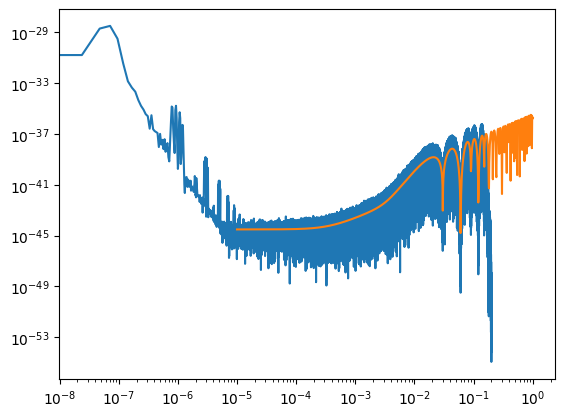

In [19]:
plt.loglog(fw, Xw)
plt.loglog(fnoise, Cxx / laser_freq**2)

# check the noise app output

In [49]:
rundir = './'

In [50]:
datadir = os.path.join(rundir,'data')
os.listdir(datadir)

['dwt_data.dat',
 'instrument_noise_model.dat',
 'scaleogram_data.dat',
 'dft_data.dat',
 'final_instrument_noise_model.dat',
 'full_noise_model.dat',
 'full_noise_model_unequal.dat',
 'whitened_data.dat',
 'power_data.dat']

In [51]:
scaleogram_data = np.loadtxt(os.path.join(datadir,'scaleogram_data.dat'))
full_noise      = np.loadtxt(os.path.join(datadir,'full_noise_model.dat'))
dwt_data        = np.loadtxt(os.path.join(datadir,'dwt_data.dat'))

In [52]:
import matplotlib_inline.backend_inline
from matplotlib import colors
%matplotlib inline

def get_Nt_Nf(datafile_arr):
    # cols are t, f, ...
    Nf = np.unique(datafile_arr[:,1]).shape[0]
    Nt = np.unique(datafile_arr[:,0]).shape[0]
    assert Nt*Nf == datafile_arr.shape[0]
    return Nt,Nf

def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr', cx_norm='abs', logf=False):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    shading = 'auto'
    tp = t[::Nf]
    fp = f[:Nf]
    if Nt == 1:
        tp = np.array([tp[0], dwt_data[-1,0]])
        fp = np.hstack([fp, fp[-1] + (fp[1]-fp[0])])
    m = ax.pcolormesh(tp, fp, z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading=shading, snap=True, rasterized=True)
    if logf:
        ax.set_yscale('log')
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

In [53]:
Nt,Nf = get_Nt_Nf(full_noise)

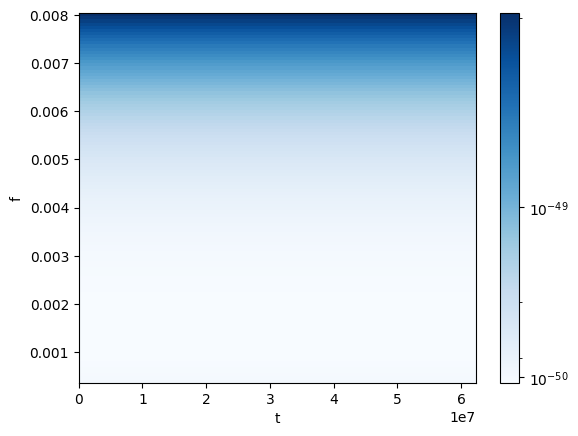

In [54]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=Nt, lognorm=True, clip = 0, cmap='Blues', logf=False)

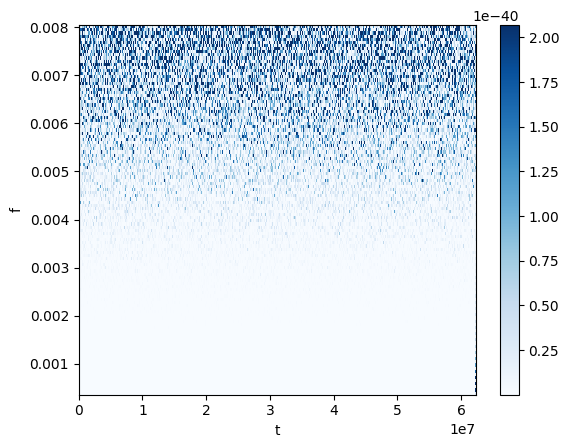

In [55]:
wavelet_specgram(scaleogram_data[:,0],
                 scaleogram_data[:,1],
                 scaleogram_data[:,2],
                 Nt=Nt,
                 lognorm=False,
                cmap = 'Blues',
                clip = 5)

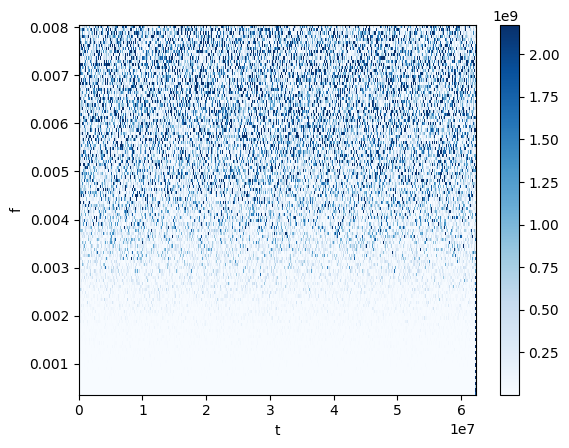

In [56]:
wavelet_specgram(scaleogram_data[:,0],
                 scaleogram_data[:,1],
                 scaleogram_data[:,2] / full_noise[:,2],
                 Nt=Nt,
                 lognorm=False,
                cmap = 'Blues',
                clip = 5)

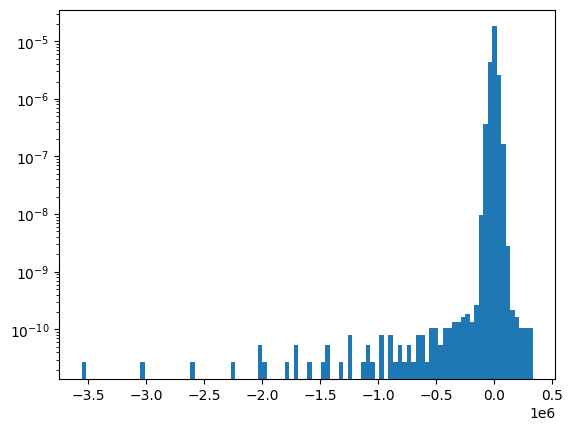

In [57]:
# gaussianity test of generated data
# fudge_factor = 3 # implemented in code
counts,bins,_ = plt.hist(dwt_data[:,4] / np.sqrt(full_noise[:,4]), density=True, bins=100)
x = np.linspace(bins[0],bins[-1],100)
plt.plot(x, np.exp(-x**2 / 2)*np.max(counts), color='k', linestyle = '--')
plt.yscale('log')

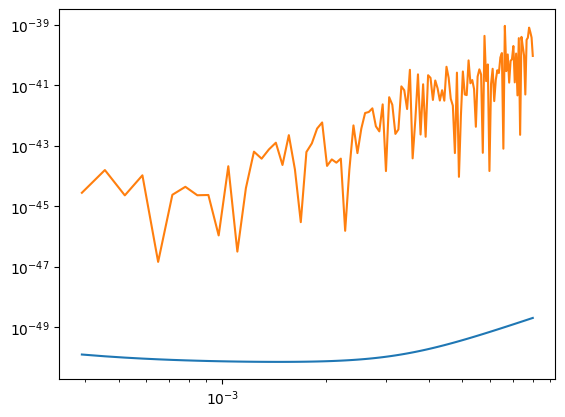

In [58]:
l = 500
emin = l*Nf
emax = (l+1)*Nf
plt.loglog(full_noise[emin:emax,1], full_noise[emin:emax,2])
plt.loglog(scaleogram_data[emin:emax,1], scaleogram_data[emin:emax,2])